# Preprocessing steps for different ML Pipelines

In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.impute import SimpleImputer

from helpers.plotting import *

DATA_PATH = "./data/"
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

## Preprocessing for Linear Regression

In [2]:
train = pl.read_csv(DATA_PATH + "train.csv")

train.schema

Schema([('id', Int64),
        ('Podcast_Name', String),
        ('Episode_Title', String),
        ('Episode_Length_minutes', Float64),
        ('Genre', String),
        ('Host_Popularity_percentage', Float64),
        ('Publication_Day', String),
        ('Publication_Time', String),
        ('Guest_Popularity_percentage', Float64),
        ('Number_of_Ads', Float64),
        ('Episode_Sentiment', String),
        ('Listening_Time_minutes', Float64)])

- handle missing values
- removing outliers (linear regression only)
- dealing with categorical variables
- feature engineering
- train-val split (test by submitting on kaggle)
- scaling

We can begin by dropping the ID since there is zero use for this in modelling

In [3]:
train.drop_in_place("id")

id
i64
0
1
2
3
4
…
749995
749996
749997


### Missing values and outliers

In [4]:
train.null_count()

Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,87093,0,0,0,0,146030,1,0,0


It seems that there are only 3 columns with missing values. We can just drop the single entry of number of ads that is null since the overhead for guessing a good value to impute is higher than just not using this data point amidst 749.999 others

In [5]:
train_no_ads_null = train.drop_nulls("Number_of_Ads")

In [6]:
train_no_ads_null.null_count()

Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,87093,0,0,0,0,146030,0,0,0


There are still other two cols with missing values. Let us begin with Episode Length

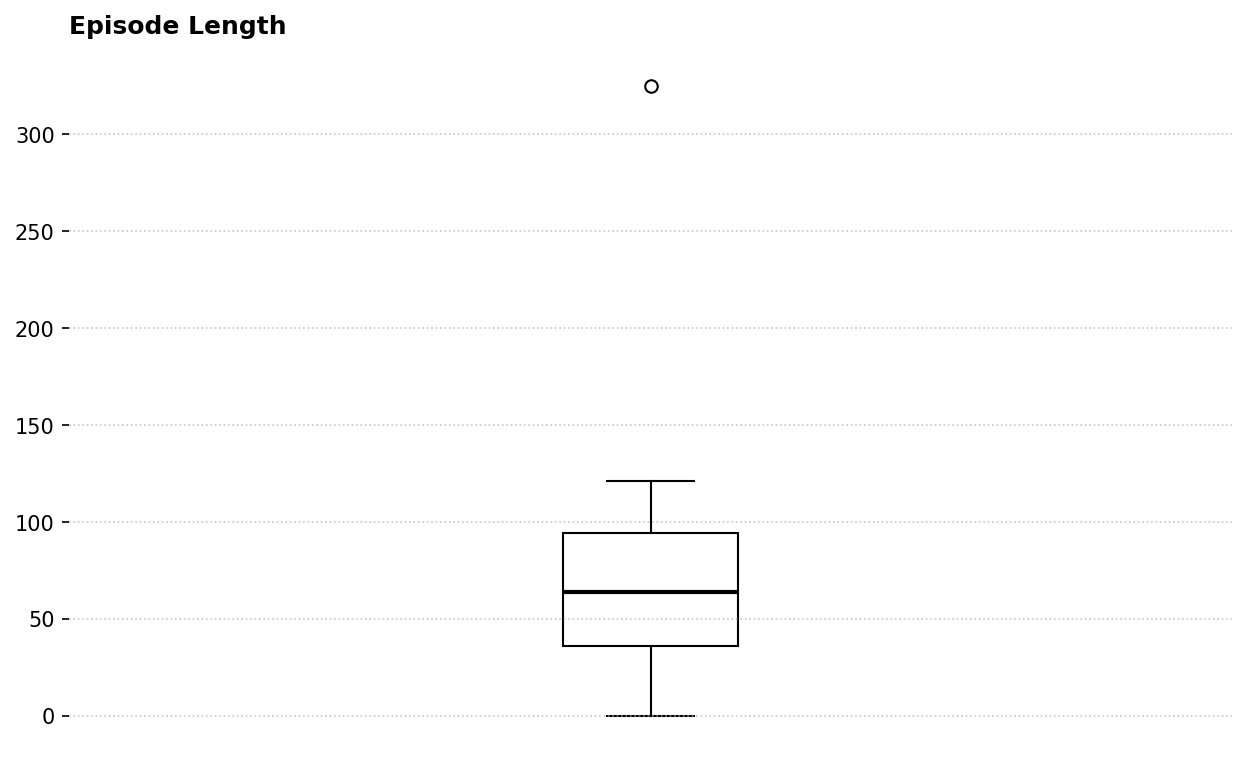

In [7]:
boxplot(train_no_ads_null["Episode_Length_minutes"].drop_nulls(), "Episode Length")

Episode Length, as we saw on the last notebook, contains an outlier which should be removed for linear regression, since this model is sensitive to them. Alternatives such as Tree based models wouldn't have such issue

In [8]:
train_no_ads_null["Episode_Length_minutes"].describe()

statistic,value
str,f64
"""count""",662906.0
"""null_count""",87093.0
"""mean""",64.504782
"""std""",32.969609
"""min""",0.0
"""25%""",35.73
"""50%""",63.84
"""75%""",94.07
"""max""",325.24


In [9]:
train_no_ads_null["Episode_Length_minutes"].max() / 60

5.4206666666666665

In [10]:
max_length = train_no_ads_null["Episode_Length_minutes"].max()

# train_no_ads_null[train_no_ads_null["Episode_Length_minutes"] == max_length]
train_no_ads_null.filter(pl.col("Episode_Length_minutes") == max_length)

Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
str,str,f64,str,f64,str,str,f64,f64,str,f64
"""Home & Living""","""Episode 16""",325.24,"""Lifestyle""",50.69,"""Tuesday""","""Afternoon""",15.01,0.0,"""Positive""",64.31981


Since this is a single occurrence in 750.000 entries, we shall remove this entry to prevent any form of skewing and improve generalization since all other data is located much lower than this point

In [11]:
q1 = train.select(pl.col("Episode_Length_minutes").quantile(0.25)).item()
q3 = train.select(pl.col("Episode_Length_minutes").quantile(0.75)).item()
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

length_col = pl.col("Episode_Length_minutes")

train_no_length_outliers = train_no_ads_null.filter((length_col <= upper_fence) | length_col.is_null())
train_no_length_outliers.describe()

statistic,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
str,str,str,f64,str,f64,str,str,f64,f64,str,f64
"""count""","""749998""","""749998""",662905.0,"""749998""",749998.0,"""749998""","""749998""",603968.0,749998.0,"""749998""",749998.0
"""null_count""","""0""","""0""",87093.0,"""0""",0.0,"""0""","""0""",146030.0,0.0,"""0""",0.0
"""mean""",null,null,64.504389,null,59.859956,null,null,52.236514,1.348857,null,45.43741
"""std""",null,null,32.968079,null,22.873095,null,null,28.451248,1.15113,null,27.138322
"""min""","""Athlete's Arena""","""Episode 1""",0.0,"""Business""",1.3,"""Friday""","""Afternoon""",0.0,0.0,"""Negative""",0.0
"""25%""",null,null,35.73,null,39.41,null,null,28.38,0.0,null,23.17835
"""50%""",null,null,63.84,null,60.05,null,null,53.58,1.0,null,43.37946
"""75%""",null,null,94.07,null,79.53,null,null,76.6,2.0,null,64.81158
"""max""","""World Watch""","""Episode 99""",120.93,"""True Crime""",119.46,"""Wednesday""","""Night""",119.91,103.91,"""Positive""",119.97


Now the maximum length is about two hours. Now we shall impute the missing values. We should check if there is any clear correlation between genre and episode length. Alternative, by podcast name and length

In [12]:
def pivot_table_on_column(table: pl.DataFrame, column: str, col_for_distribution: str) -> pl.DataFrame:
    col_values = table[column].unique().limit(10).to_list()

    data_by_col = {
        col: table.filter(pl.col(column) == col)[col_for_distribution].to_list()
        for col in col_values
    }

    # Determine the maximum length
    max_len = max(len(v) for v in data_by_col.values())

    # Pad all lists to max length with None
    padded_data = {
        col: values + [None] * (max_len - len(values))
        for col, values in data_by_col.items()
    }

    # Now create the DataFrame safely
    wide_by_col = pl.DataFrame(padded_data)
    return wide_by_col, col_values

In [13]:
# top_genres = train_no_length_outliers["Genre"].unique().to_list()

# data_by_genre = {
#     genre: train_no_length_outliers.filter(pl.col("Genre") == genre)["Episode_Length_minutes"].to_list()
#     for genre in top_genres
# }

# # Determine the maximum length
# max_len = max(len(v) for v in data_by_genre.values())

# # Pad all lists to max length with None
# padded_data = {
#     genre: values + [None] * (max_len - len(values))
#     for genre, values in data_by_genre.items()
# }

# # Now create the DataFrame safely
# wide_by_genre = pl.DataFrame(padded_data)
# wide_by_genre

wide_by_genre, genres = pivot_table_on_column(train_no_length_outliers, "Genre", "Episode_Length_minutes")

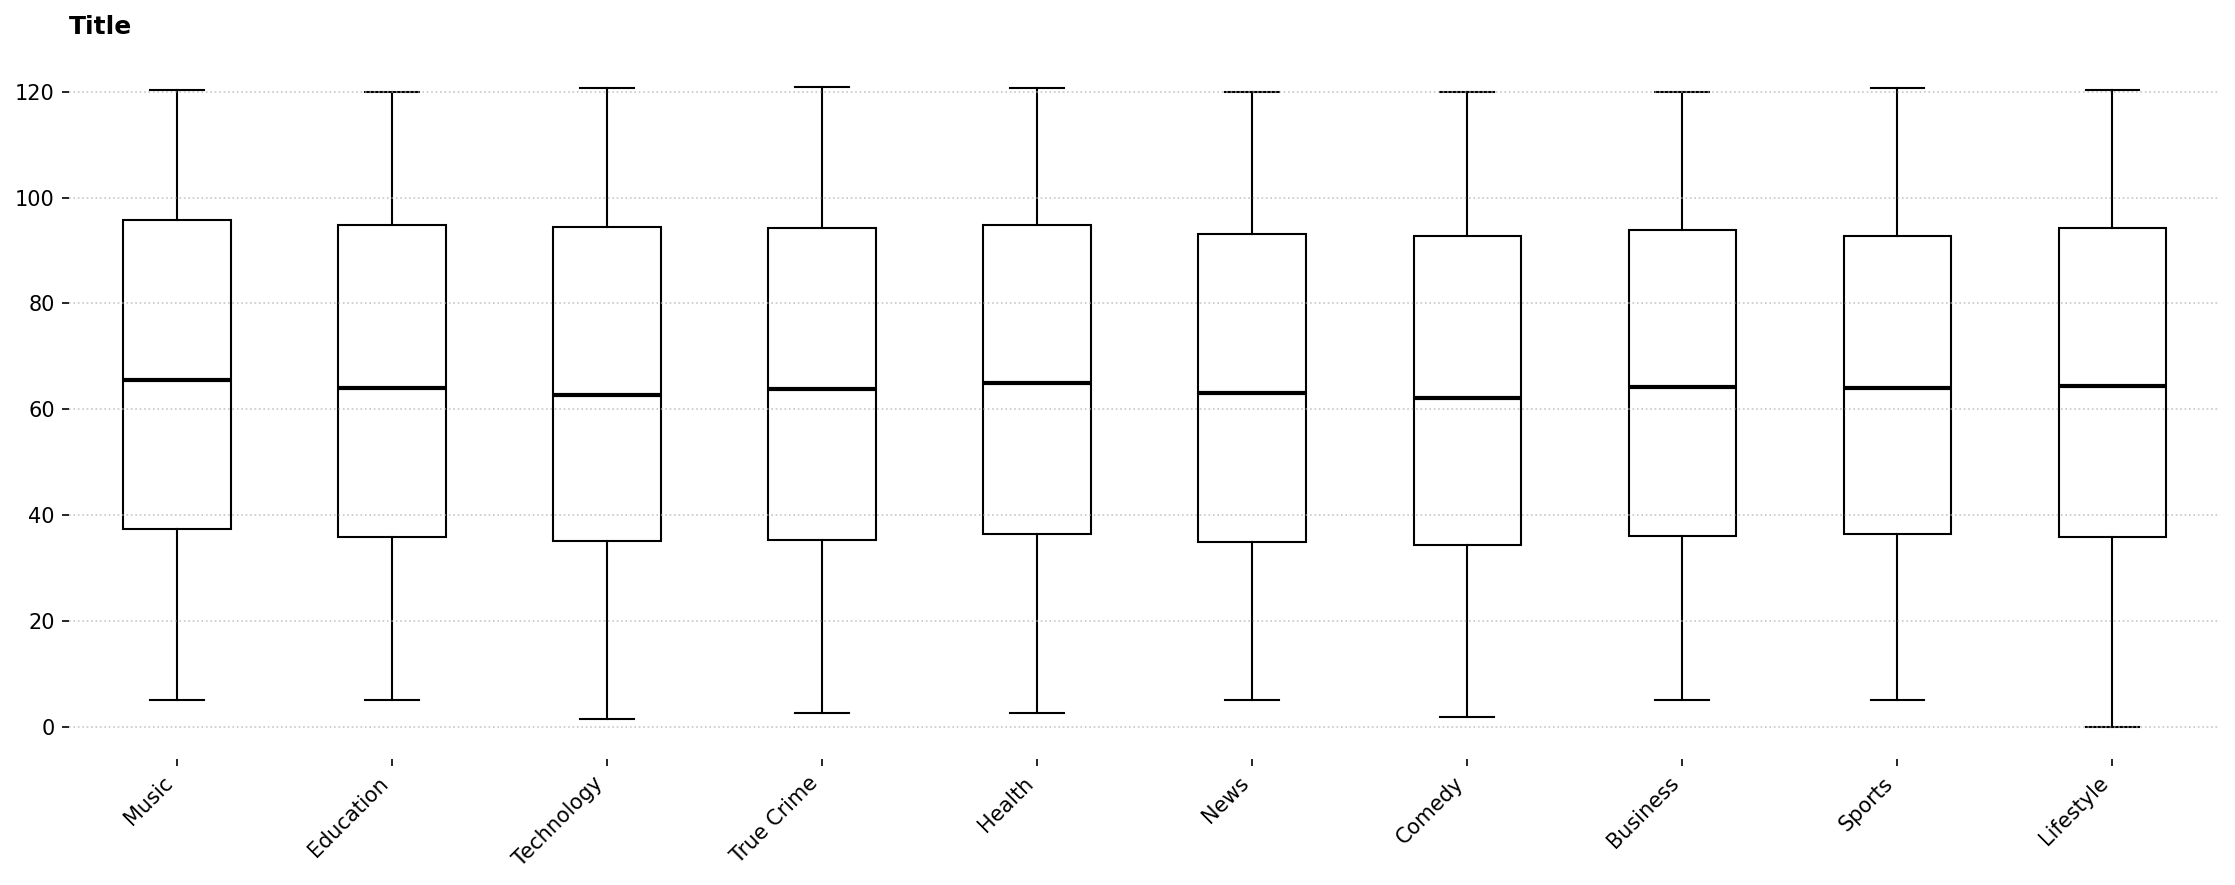

In [14]:
multiple_boxplots(wide_by_genre, genres)

Distributions of episode length seem to not differ by genre. Let's check 10 podcast names to see if any patterns arise. In case not, we can just impute with random sampling

In [15]:
wide_by_podcast, podcasts = pivot_table_on_column(train_no_length_outliers, "Podcast_Name", "Episode_Length_minutes")
wide_by_podcast

Mystery Matters,Crime Chronicles,Sports Weekly,Game Day,Business Briefs,Mind & Body,Funny Folks,Gadget Geek,News Roundup,Athlete's Arena
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
null,82.69,67.05,82.14,66.22,110.51,54.67,92.5,48.52,11.68
57.93,80.33,110.7,33.02,12.52,92.81,5.83,null,60.34,72.63
94.45,null,31.69,111.15,22.03,84.5,null,90.96,118.67,77.95
23.74,39.67,25.74,45.95,67.87,93.16,39.74,65.58,37.74,19.56
108.34,103.11,49.65,null,91.32,null,106.27,32.01,13.24,87.96
…,…,…,…,…,…,…,…,…,…
null,null,111.19,null,null,null,null,null,null,null
null,null,23.68,null,null,null,null,null,null,null
null,null,44.38,null,null,null,null,null,null,null


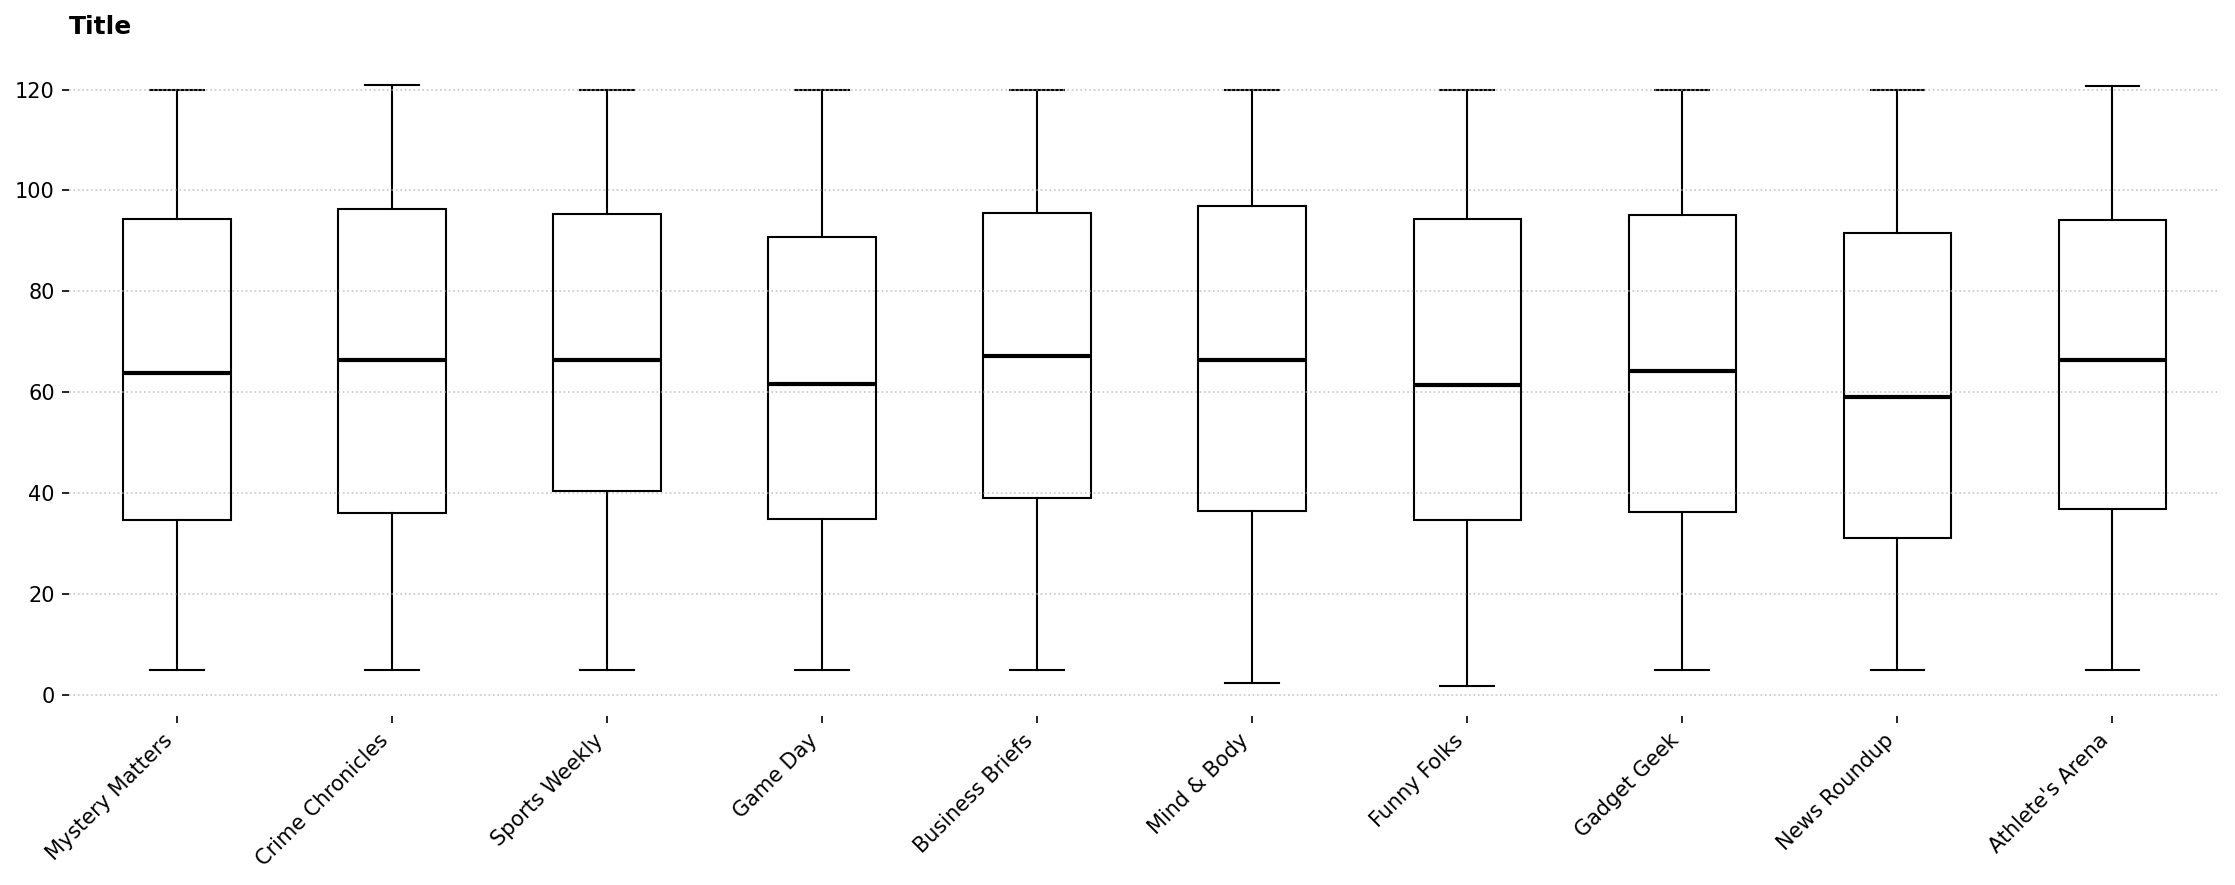

In [16]:
multiple_boxplots(wide_by_podcast, podcasts)

No patterns arised. Let us impute by random sampling

In [17]:
def sample_imputer(col: np.ndarray):
    return np.mean(np.random.choice(col, len(col)//10))

random_sampling_imputer = SimpleImputer(missing_values=np.nan, strategy=sample_imputer)

In [18]:
imputed_length = random_sampling_imputer.fit_transform(train_no_length_outliers["Episode_Length_minutes"].to_numpy().reshape(-1, 1))
imputed_length = pl.Series("Episode_Length_minutes", imputed_length.ravel())

In [19]:
train_no_length_outliers = train_no_length_outliers.with_columns(imputed_length)

In [20]:
train_no_length_outliers.null_count()

Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,146030,0,0,0


Now we shall do the same analysis for Guest Popularity

In [21]:
train_no_length_outliers["Guest_Popularity_percentage"].describe()

statistic,value
str,f64
"""count""",603968.0
"""null_count""",146030.0
"""mean""",52.236514
"""std""",28.451248
"""min""",0.0
"""25%""",28.38
"""50%""",53.58
"""75%""",76.6
"""max""",119.91


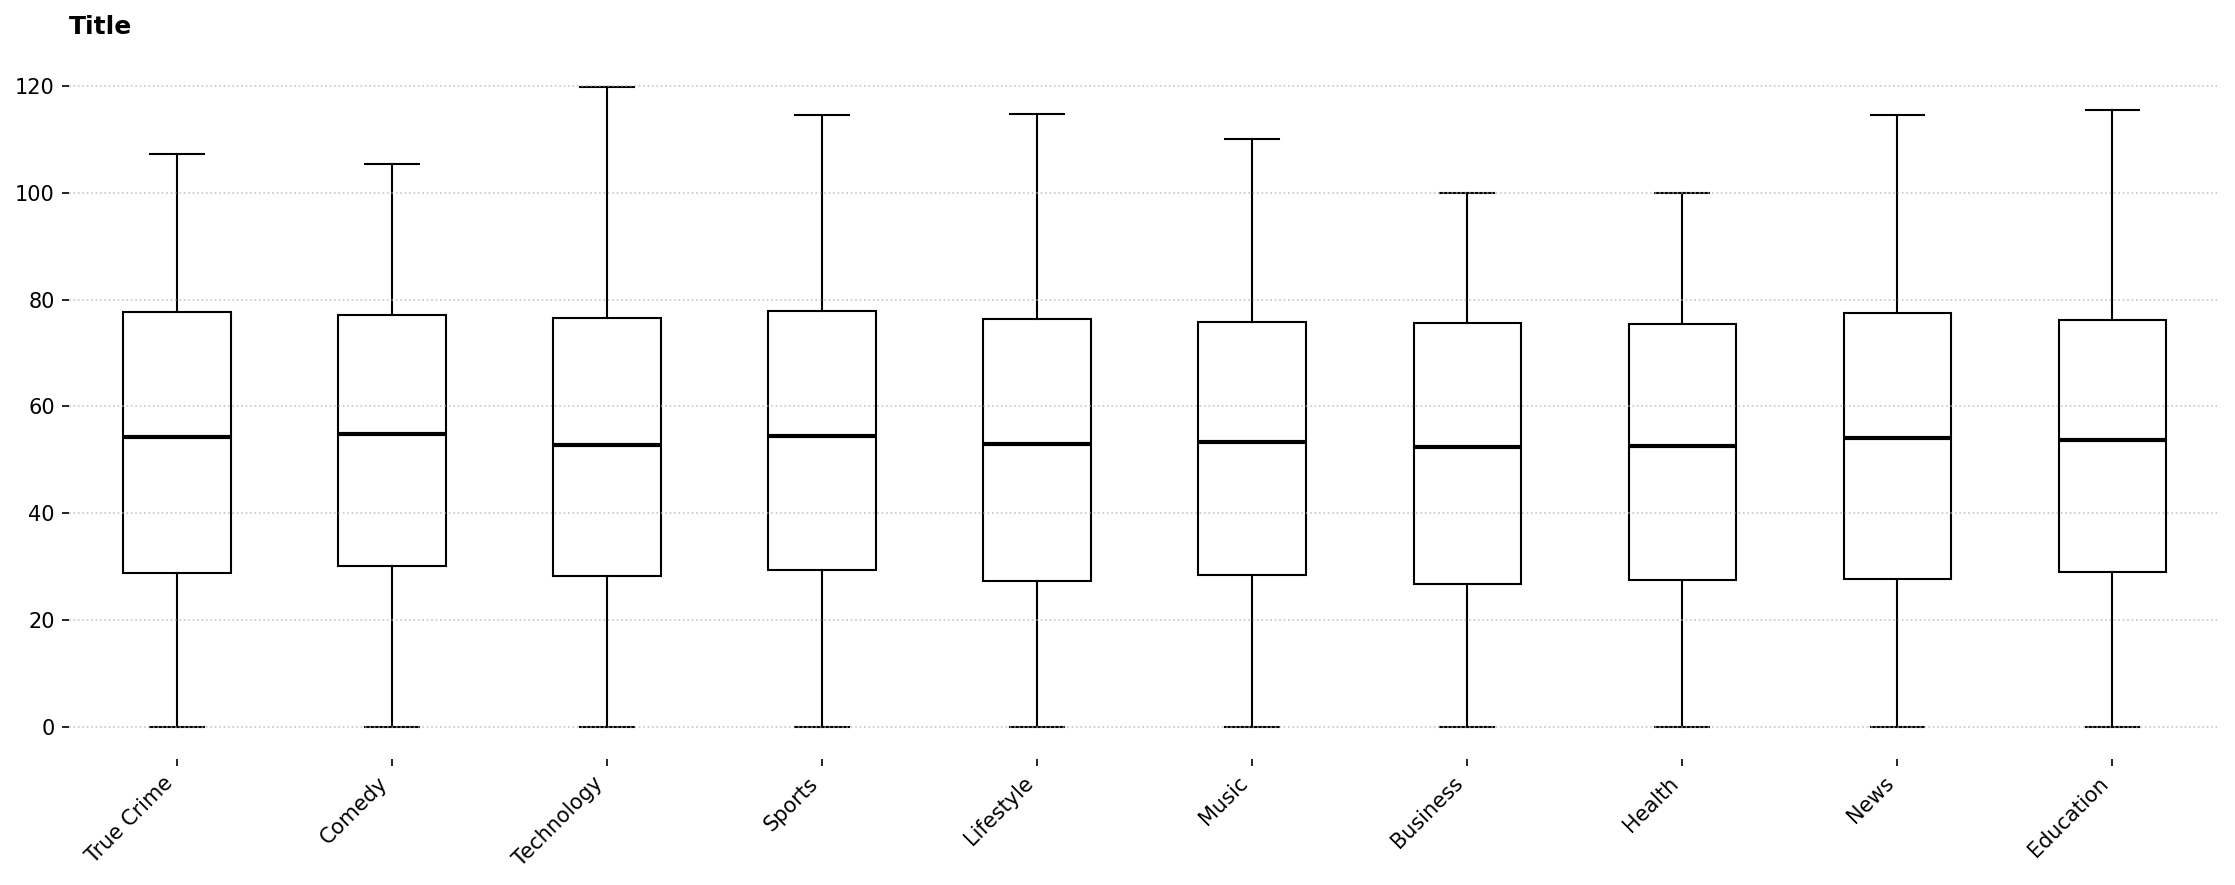

In [22]:
wide_on_genre_pop, cols_genre_pop = pivot_table_on_column(train_no_length_outliers, "Genre", "Guest_Popularity_percentage")
multiple_boxplots(wide_on_genre_pop, cols_genre_pop)

Percentages should stop at 100 as per the original dataset https://www.kaggle.com/datasets/ysthehurricane/podcast-listening-time-prediction-dataset. This synthetic one has values way beyond 100. Makes no sense. 

In [23]:
outliers_guest_percentage = train_no_length_outliers.filter(pl.col("Guest_Popularity_percentage") > 100)
outliers_guest_percentage.count()

Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
19,19,19,19,19,19,19,19,19,19,19


Seems that there are only 19 podcasts total with these outliers. This value is a wrong measurement so they should be dropped

In [24]:
pop_percent = pl.col("Guest_Popularity_percentage")

train_no_guest_outl = train_no_length_outliers.filter((pop_percent <= 100) | (pop_percent.is_null()))
train_no_guest_outl["Guest_Popularity_percentage"].describe()

statistic,value
str,f64
"""count""",603949.0
"""null_count""",146030.0
"""mean""",52.234687
"""std""",28.449815
"""min""",0.0
"""25%""",28.38
"""50%""",53.58
"""75%""",76.6
"""max""",99.99


In [25]:
train_no_guest_outl.null_count()

Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,146030,0,0,0


In [26]:
imputed_pop = random_sampling_imputer.fit_transform(train_no_guest_outl["Guest_Popularity_percentage"].to_numpy().reshape(-1, 1))
imputed_pop = pl.Series("Guest_Popularity_percentage", imputed_pop.ravel())

train_no_guest_outl = train_no_guest_outl.with_columns(imputed_pop)
train_no_guest_outl.describe()

statistic,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
str,str,str,f64,str,f64,str,str,f64,f64,str,f64
"""count""","""749979""","""749979""",749979.0,"""749979""",749979.0,"""749979""","""749979""",749979.0,749979.0,"""749979""",749979.0
"""null_count""","""0""","""0""",0.0,"""0""",0.0,"""0""","""0""",0.0,0.0,"""0""",0.0
"""mean""",null,null,64.541474,null,59.859972,null,null,52.211523,1.348875,null,45.437609
"""std""",null,null,30.995066,null,22.873173,null,null,25.530287,1.151132,null,27.138473
"""min""","""Athlete's Arena""","""Episode 1""",0.0,"""Business""",1.3,"""Friday""","""Afternoon""",0.0,0.0,"""Negative""",0.0
"""25%""",null,null,39.42,null,39.41,null,null,34.55,0.0,null,23.17835
"""50%""",null,null,64.821595,null,60.05,null,null,52.115721,1.0,null,43.37953
"""75%""",null,null,90.31,null,79.53,null,null,71.04,2.0,null,64.81158
"""max""","""World Watch""","""Episode 99""",120.93,"""True Crime""",119.46,"""Wednesday""","""Night""",99.99,103.91,"""Positive""",119.97


In [27]:
train_no_guest_outl.null_count()

Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0


Seems the null values have been dealt with. Let's verify if there are any more outliers in numerical columns

/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_48501/4185349550.py:1: DeprecationWarning: `NUMERIC_DTYPES` is deprecated. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  for col in train_no_guest_outl.select(pl.col(pl.NUMERIC_DTYPES)).columns:


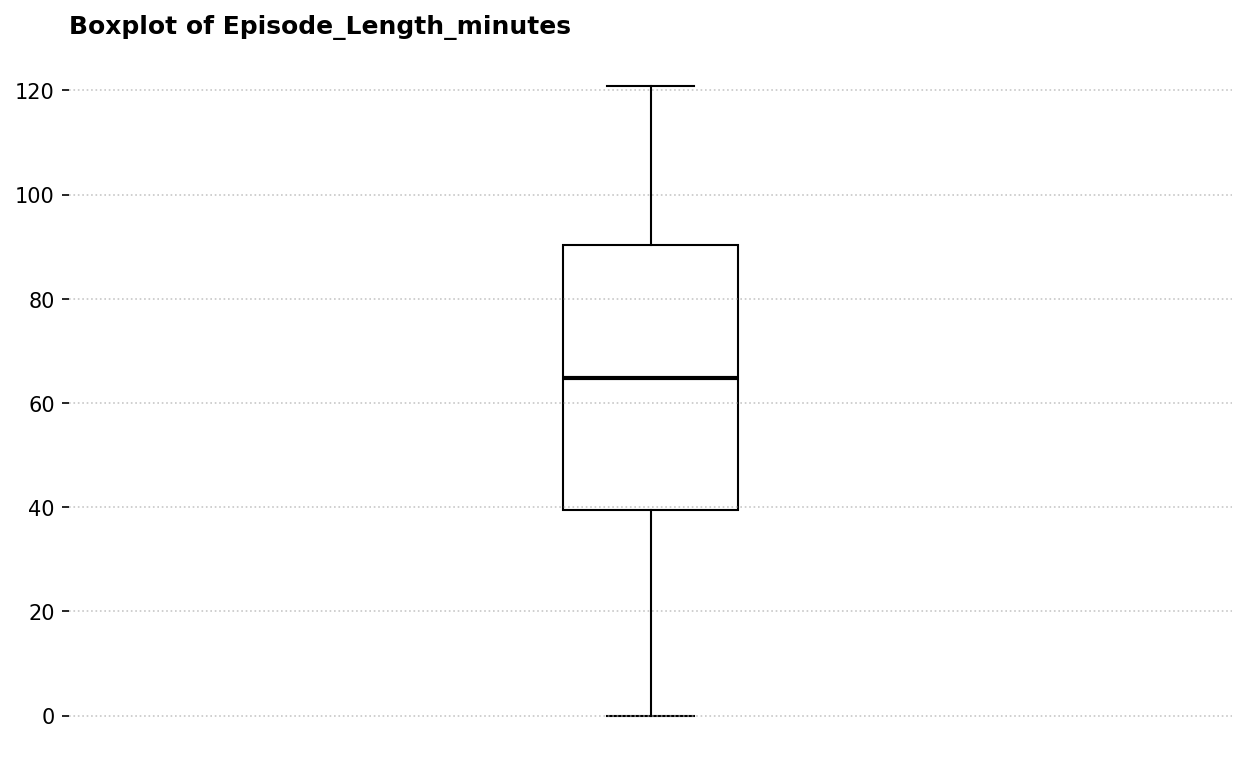

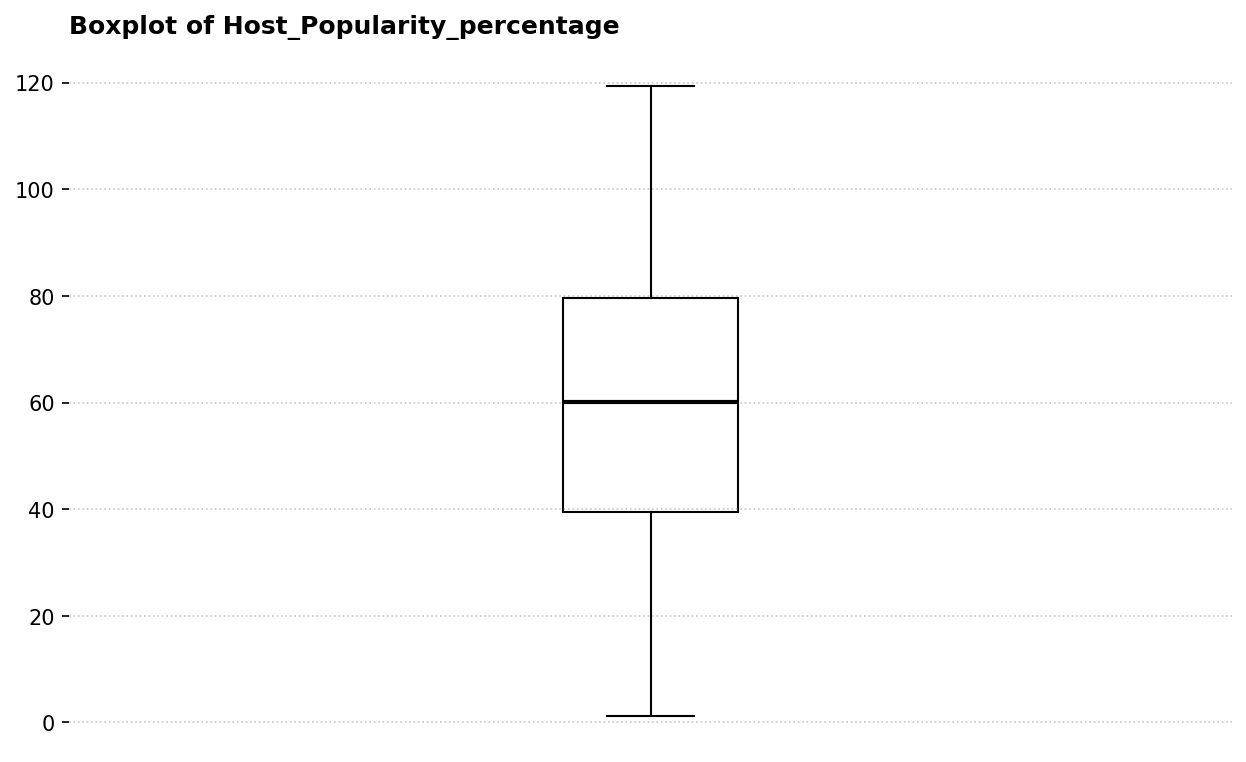

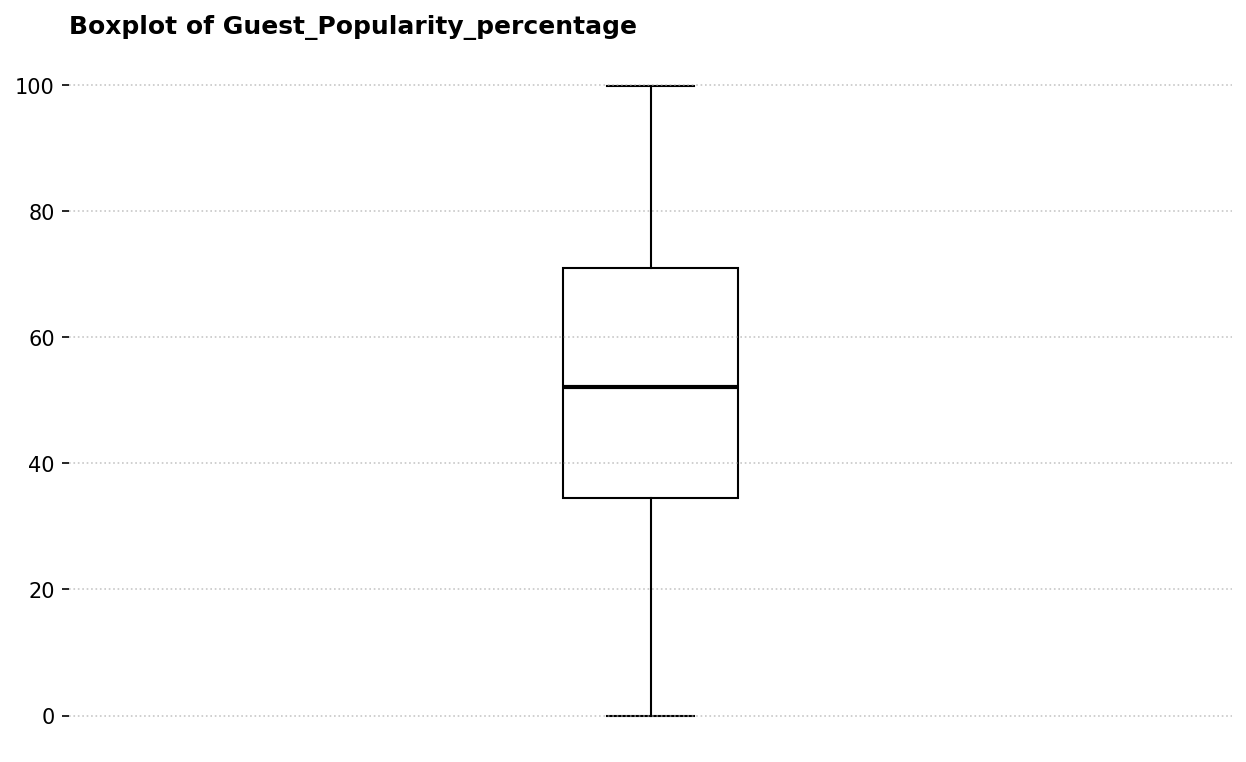

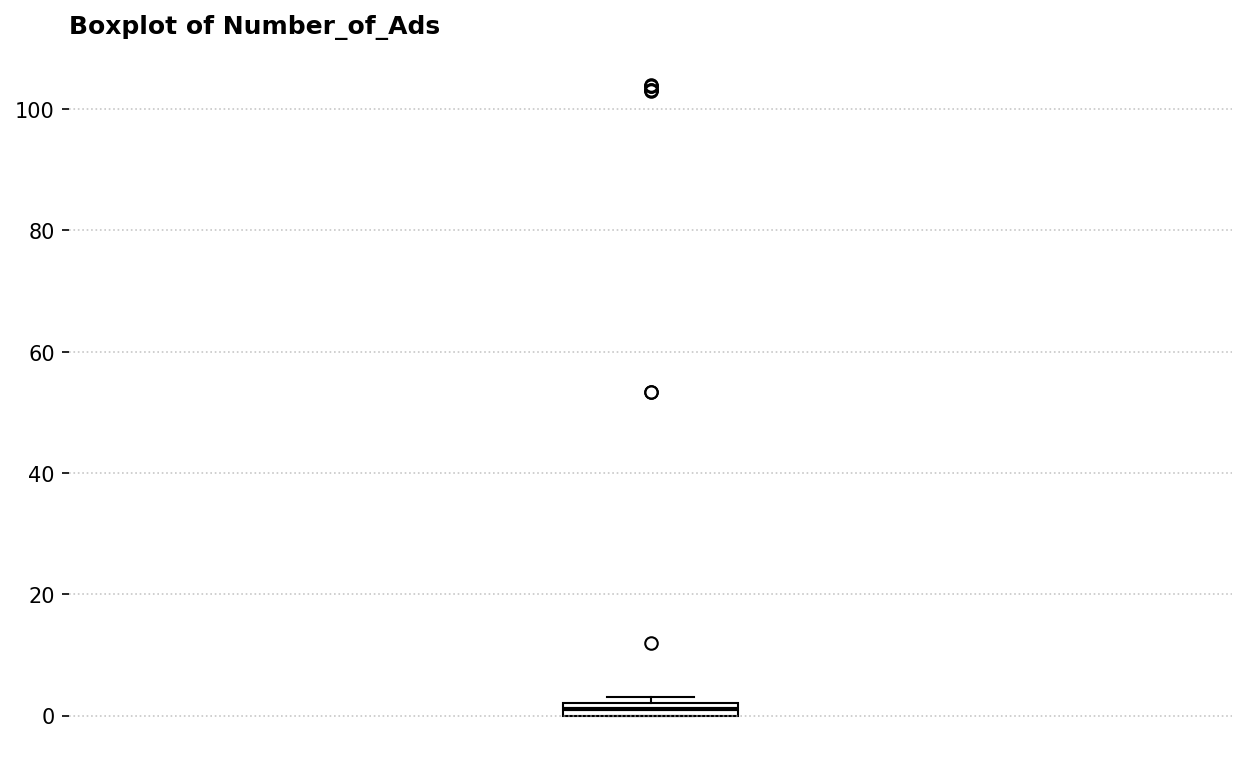

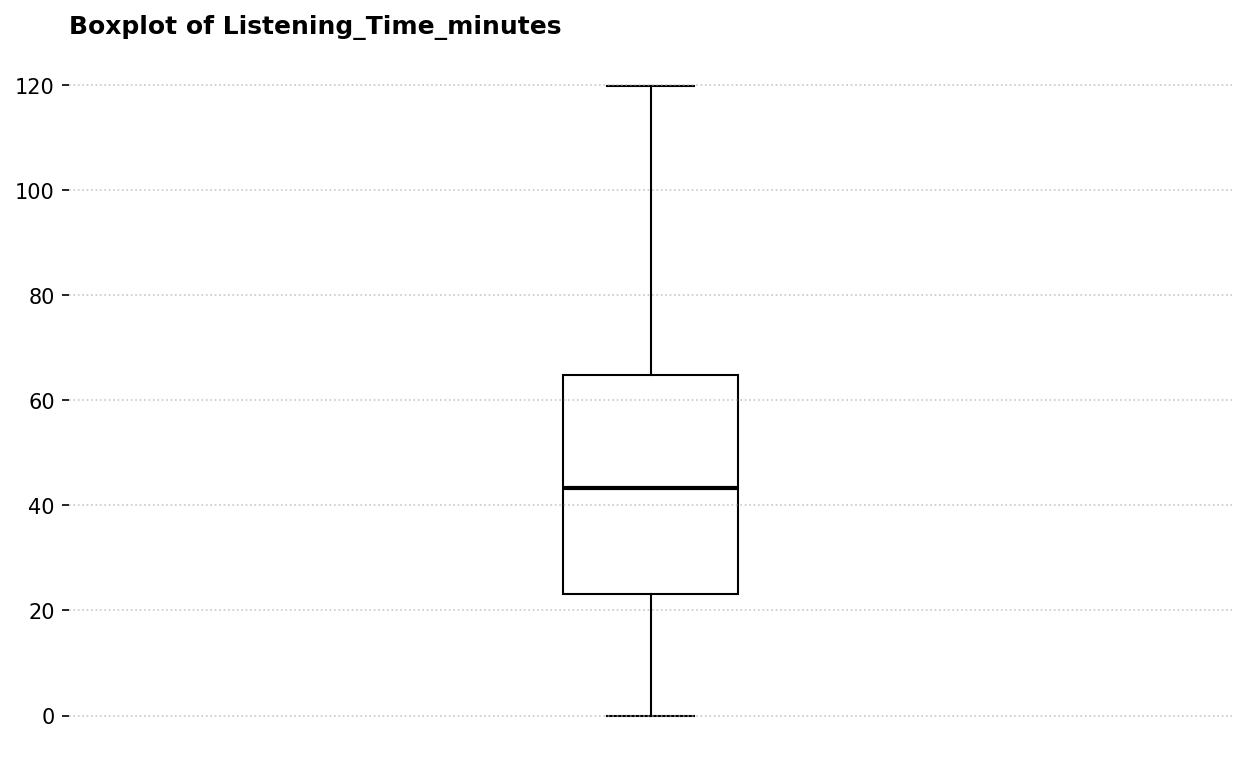

In [28]:
for col in train_no_guest_outl.select(pl.col(pl.NUMERIC_DTYPES)).columns:
    boxplot(train_no_guest_outl[col], f"Boxplot of {col}")

Again we see the number of Ads has several outliers. Crossing the 100 mark

In [29]:

q1 = train.select(pl.col("Number_of_Ads").quantile(0.25)).item()
q3 = train.select(pl.col("Number_of_Ads").quantile(0.75)).item()
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

n_of_ads_outliers = train.filter(pl.col("Number_of_Ads") > upper_fence)
n_of_ads_outliers

Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
str,str,f64,str,f64,str,str,f64,f64,str,f64
"""Wellness Wave""","""Episode 83""",64.83,"""Health""",48.46,"""Sunday""","""Evening""",null,53.37,"""Positive""",50.44892
"""Health Hour""","""Episode 15""",109.93,"""Health""",67.81,"""Sunday""","""Morning""",77.9,103.91,"""Neutral""",103.89696
"""Sports Central""","""Episode 64""",115.25,"""Sports""",28.58,"""Saturday""","""Afternoon""",23.65,103.0,"""Neutral""",103.12686
"""Comedy Corner""","""Episode 79""",64.83,"""Comedy""",48.37,"""Saturday""","""Evening""",null,53.42,"""Neutral""",50.44892
"""Sound Waves""","""Episode 64""",112.27,"""Music""",28.95,"""Saturday""","""Morning""",10.15,103.75,"""Neutral""",103.12686
"""Detective Diaries""","""Episode 21""",16.13,"""True Crime""",49.11,"""Tuesday""","""Evening""",43.17,12.0,"""Positive""",6.49
"""Sound Waves""","""Episode 53""",112.27,"""Music""",28.19,"""Tuesday""","""Morning""",23.15,103.25,"""Neutral""",103.12686
"""Sound Waves""","""Episode 35""",115.74,"""Music""",28.95,"""Tuesday""","""Afternoon""",23.5,103.25,"""Neutral""",103.12686
"""Crime Chronicles""","""Episode 15""",109.93,"""True Crime""",59.66,"""Tuesday""","""Evening""",77.91,103.88,"""Neutral""",103.89696


I must again declare how stupid is seems to have 53.37 ads. Obviously wrongly measured. The 12 might be right but it's still above the upper fence so we will drop it as well

In [30]:
n_of_ads_no_outliers = train.filter(pl.col("Number_of_Ads") <= upper_fence)
n_of_ads_no_outliers

Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
str,str,f64,str,f64,str,str,f64,f64,str,f64
"""Mystery Matters""","""Episode 98""",null,"""True Crime""",74.81,"""Thursday""","""Night""",null,0.0,"""Positive""",31.41998
"""Joke Junction""","""Episode 26""",119.8,"""Comedy""",66.95,"""Saturday""","""Afternoon""",75.95,2.0,"""Negative""",88.01241
"""Study Sessions""","""Episode 16""",73.9,"""Education""",69.97,"""Tuesday""","""Evening""",8.97,0.0,"""Negative""",44.92531
"""Digital Digest""","""Episode 45""",67.17,"""Technology""",57.22,"""Monday""","""Morning""",78.7,2.0,"""Positive""",46.27824
"""Mind & Body""","""Episode 86""",110.51,"""Health""",80.07,"""Monday""","""Afternoon""",58.68,3.0,"""Neutral""",75.61031
…,…,…,…,…,…,…,…,…,…,…
"""Learning Lab""","""Episode 25""",75.66,"""Education""",69.36,"""Saturday""","""Morning""",null,0.0,"""Negative""",56.87058
"""Business Briefs""","""Episode 21""",75.75,"""Business""",35.21,"""Saturday""","""Night""",null,2.0,"""Neutral""",45.46242
"""Lifestyle Lounge""","""Episode 51""",30.98,"""Lifestyle""",78.58,"""Thursday""","""Morning""",84.89,0.0,"""Negative""",15.26


In [31]:
train_no_guest_outl = train_no_guest_outl.filter(pl.col("Number_of_Ads") <= upper_fence)
train_no_guest_outl.describe()

statistic,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
str,str,str,f64,str,f64,str,str,f64,f64,str,f64
"""count""","""749970""","""749970""",749970.0,"""749970""",749970.0,"""749970""","""749970""",749970.0,749970.0,"""749970""",749970.0
"""null_count""","""0""","""0""",0.0,"""0""",0.0,"""0""","""0""",0.0,0.0,"""0""",0.0
"""mean""",null,null,64.541153,null,59.860173,null,null,52.211638,1.347905,null,45.437184
"""std""",null,null,30.994904,null,22.873184,null,null,25.530292,1.110968,null,27.138102
"""min""","""Athlete's Arena""","""Episode 1""",0.0,"""Business""",1.3,"""Friday""","""Afternoon""",0.0,0.0,"""Negative""",0.0
"""25%""",null,null,39.42,null,39.41,null,null,34.55,0.0,null,23.17835
"""50%""",null,null,64.821595,null,60.05,null,null,52.115721,1.0,null,43.37946
"""75%""",null,null,90.31,null,79.53,null,null,71.04,2.0,null,64.81158
"""max""","""World Watch""","""Episode 99""",120.93,"""True Crime""",119.46,"""Wednesday""","""Night""",99.99,3.0,"""Positive""",119.97


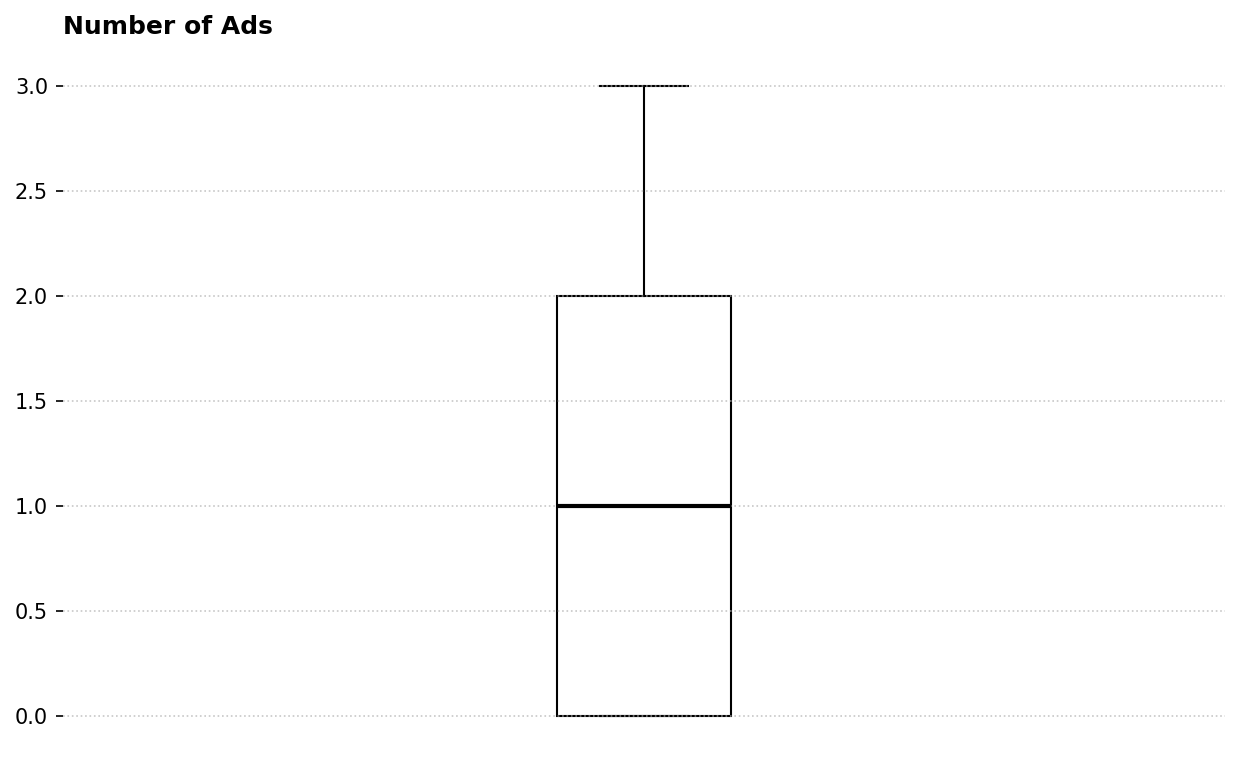

In [32]:
boxplot(train_no_guest_outl["Number_of_Ads"], "Number of Ads")

Looks good now. Let's save this df into a CSV file for reference

In [33]:
for col in train_no_guest_outl.schema:
    if "array" in str(train_no_guest_outl.schema[col]):
        print(f"{col}: {train_no_guest_outl.schema[col]}")


In [34]:
train_no_guest_outl.schema

Schema([('Podcast_Name', String),
        ('Episode_Title', String),
        ('Episode_Length_minutes', Float64),
        ('Genre', String),
        ('Host_Popularity_percentage', Float64),
        ('Publication_Day', String),
        ('Publication_Time', String),
        ('Guest_Popularity_percentage', Float64),
        ('Number_of_Ads', Float64),
        ('Episode_Sentiment', String),
        ('Listening_Time_minutes', Float64)])

In [35]:
train_no_guest_outl.write_csv(DATA_PATH + "train_imputed_no_outliers.csv")

### Encoding Categorical Values

The challenge with encoding categorical variables for linear regression is avoiding giving the model the idea of magnitude with a Label Encoder, for instance. As a Tree based model would look at a label and just decide whether to branch to the left or the right, a numerical label on a curve-fitting model like a linear regression means how large that variable is, and it is going to try to fit a weight to determine the influence of that variable in the final result. The alternative would be to One-Hot encode the variable, creating a dummy variable for each possibility of category, where the de facto category gets a 1 and the others get a 0, thus eliminating their influence on the final result. In tree based models, in the other hand, this would not be a good idea for a very large set of categories, since a 0 in a tree based model does not imply in zero influence, and the model would still consider all dummy variables for all possible categories, thus falling into the curse of dimensionality

In [40]:
one_hot_encoded_train = train_no_guest_outl \
    .to_dummies("Podcast_Name") \
    .to_dummies("Genre") \
    .to_dummies("Publication_Day") \
    .to_dummies("Publication_Time") \
    .to_dummies("Episode_Sentiment")
one_hot_encoded_train.schema

Schema([("Podcast_Name_Athlete's Arena", UInt8),
        ('Podcast_Name_Brain Boost', UInt8),
        ('Podcast_Name_Business Briefs', UInt8),
        ('Podcast_Name_Business Insights', UInt8),
        ('Podcast_Name_Comedy Corner', UInt8),
        ('Podcast_Name_Crime Chronicles', UInt8),
        ('Podcast_Name_Criminal Minds', UInt8),
        ('Podcast_Name_Current Affairs', UInt8),
        ('Podcast_Name_Daily Digest', UInt8),
        ('Podcast_Name_Detective Diaries', UInt8),
        ('Podcast_Name_Digital Digest', UInt8),
        ('Podcast_Name_Educational Nuggets', UInt8),
        ('Podcast_Name_Fashion Forward', UInt8),
        ('Podcast_Name_Finance Focus', UInt8),
        ('Podcast_Name_Fitness First', UInt8),
        ('Podcast_Name_Funny Folks', UInt8),
        ('Podcast_Name_Gadget Geek', UInt8),
        ('Podcast_Name_Game Day', UInt8),
        ('Podcast_Name_Global News', UInt8),
        ('Podcast_Name_Health Hour', UInt8),
        ('Podcast_Name_Healthy Living', UInt8),
 

There's also the matter of Episode Title, which should not influence how much time a person listens the podcast, and in fact does not correlate to it at all. Let's drop it

In [ ]:
one_hot_encoded_train = one_hot_encoded_train.drop("Episode_Title")
one_hot_encoded_train

Let's save this dataframe just for reference

In [44]:
one_hot_encoded_train.write_csv(DATA_PATH + "one_hot_encoded_for_lr.csv")

In [ ]:
def preprocessing_for_lr(df: pl.DataFrame) -> pl.DataFrame:
    dropped_id_and_title = df.drop("id", "Episode_Title")
    one_hot_encoded = dropped_id_and_title \
        .to_dummies("Podcast_Name") \
        .to_dummies("Genre") \
        .to_dummies("Publication_Day") \
        .to_dummies("Publication_Time") \
        .to_dummies("Episode_Sentiment")
    
    return one_hot_encoded

## Preprocessing for Tree-based models

The only difference I'll tackle here is not one-hot encoding variables but just label-encoding them instead since the magnitude of a feature is not important for computing targets in a tree-based model

In [ ]:
train_no_guest_outl.label

Schema([('Podcast_Name', String),
        ('Episode_Title', String),
        ('Episode_Length_minutes', Float64),
        ('Genre', String),
        ('Host_Popularity_percentage', Float64),
        ('Publication_Day', String),
        ('Publication_Time', String),
        ('Guest_Popularity_percentage', Float64),
        ('Number_of_Ads', Float64),
        ('Episode_Sentiment', String),
        ('Listening_Time_minutes', Float64)])

In [52]:
label_encoded_train = train_no_guest_outl.with_columns(
    pl.col("Genre").cast(pl.Categorical).to_physical(),
    pl.col("Podcast_Name").cast(pl.Categorical).to_physical(),
    pl.col("Publication_Day").cast(pl.Categorical).to_physical(),
    pl.col("Publication_Time").cast(pl.Categorical).to_physical(),
    pl.col("Episode_Sentiment").cast(pl.Categorical).to_physical(),
).drop("Episode_Title")

label_encoded_train

Podcast_Name,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
u32,f64,u32,f64,u32,u32,f64,f64,u32,f64
0,64.821595,0,74.81,0,0,52.115721,0.0,0,31.41998
1,119.8,1,66.95,1,1,75.95,2.0,1,88.01241
2,73.9,2,69.97,2,2,8.97,0.0,1,44.92531
3,67.17,3,57.22,3,3,78.7,2.0,0,46.27824
4,110.51,4,80.07,3,1,58.68,3.0,2,75.61031
…,…,…,…,…,…,…,…,…,…
36,75.66,2,69.36,1,3,52.115721,0.0,1,56.87058
19,75.75,8,35.21,1,0,52.115721,2.0,2,45.46242
37,30.98,9,78.58,0,3,84.89,0.0,1,15.26


In [53]:
label_encoded_train.write_csv(DATA_PATH + "label_encoded_for_trees.csv")

In [ ]:
def preprocessing_for_trees(df: pl.DataFrame) -> pl.DataFrame:
    dropped_id_and_title = df.drop("id", "Episode_Title")
    encoded_cats = dropped_id_and_title.with_columns(
        pl.col("Genre").cast(pl.Categorical).to_physical(),
        pl.col("Podcast_Name").cast(pl.Categorical).to_physical(),
        pl.col("Publication_Day").cast(pl.Categorical).to_physical(),
        pl.col("Publication_Time").cast(pl.Categorical).to_physical(),
        pl.col("Episode_Sentiment").cast(pl.Categorical).to_physical(),
    )

    return encoded_cats